In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('./functions'))
import numpy as np
import matplotlib.pyplot as plt
from functions import lc_model
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)

## Preface

![planetary_society_transit.png](./figures/planetary_society_transit.png)

Before we launch into detecting exoplanets, it's worth breaking down exactly what "transit photometry" means. If you've taken an astronomy course before you've almost certainly encountered these terms. If so, try explaining these to your classmates in your own words. 

#### Photometry
From [Stetson 2013](https://link.springer.com/rwe/10.1007/978-94-007-5618-2_1) in *Planets, Stars and Stellar Systems*, "Astronomers use the term “photometry” to refer to the precise measurement of the apparent brightness of astronomical objects in particular specified ranges of electromagnetic wavelength in and near the optically visible band."

#### Transit
From [Britannica](https://www.britannica.com/science/transit-astronomy): **transit**, in astronomy, the passage of a relatively small body across the disk of a larger body, usually a star or a planet, occulting only a very small area.

Some things to ponder/discuss: 
- what is it called when an object is (relatively) larger passes in front of a (relatively) smaller object, blocking all of the background objects light?
- can the foreground object be (absolutely) smaller than an object it is passing in front of and still block all of the background objects light? Any examples come to mind in the Solar System?

Anywho, as this is an exoplanets class, when the notebook refers to a transit, it is refering to "the passage of an exoplanet across the disk of its host star, occulting only a small area."

## Transit probability

For someone on Earth to observe a tranist requires the planetary orbit to very nearly edge-on ($i \simeq \pi/2$). This is a low-probability event given that we can't know a priori what the inclination angle of a planet is (unless someone has observed it before) and it can take on any value between 0 and $\pi/2$ with uniform probability. As such, the transit photometry is most useful as a large survey like Kepler. The transit probability is

$$\LARGE P_\mathrm{transit} = \frac{R_\star + R_p}{a} \simeq \frac{R_\star}{a}$$

where $R_\star$ is the radius of the star, $R_p$ is the radius of the planet, and $a$ is the semi-major axis of the planet. If someone was observing the Sun, what is the probability they would see Earth transit? Mercury? How about a planet at 0.01 AU?

## The anatomy of a light curve

Detecting methods through transit photometry relies on measuring the brightness of a star as a function of time, i.e., creating a **light curve**. Let's take a look at what an idealized light curve will look like shortly before, during, and after the transit of a planet. The figure below is from [Winn 2010](https://arxiv.org/abs/1001.2010), which has a nice review of this detection technique.

![ideal_transit.png](./figures/ideal_transit.png)

### Transit depth ($\delta$)

The transit depth is the *maximum* amount of light blocked by a planet during a transit. It is determined by the ratio of the surface area of the planet ($A_p$) to that of its star ($A_\star$), which reduces to the squared ratio of the planet's radius ($R_p$) to its host's (R$_\star$):

$$\LARGE\delta = f_0\frac{A_p}{A_\star} = f_0\frac{\pi R_p^2}{\pi R_\star^2} = f_0\left(\frac{R_p}{R_\star}\right)^2$$

where $f_0$ is the baseline flux, or brightness, of the host star outside of transit. Transit light curves are generally normalized such that $f_0 = 1$. 

Below are four duration parameters, along with some approximations. With you classmates, write up your own descriptions of each. Think about the following:
- What assumptions are being made in the duration approximations? 
- What parameter in the idealistic light curve figure is likely to have the largest impact on total and full transit durations?
- In what scenarios may ingress and egress duration vary?

### *Total* transit duration: $t_\mathrm{IV} -t_\mathrm{I} \approx \frac{2(R_\star +R_p)}{v_\mathrm{K}}$
### *Full* duration: $t_\mathrm{III}-t_\mathrm{II} \approx \frac{2R_\star}{v_\mathrm{K}}$
### Ingress duration: $t_\mathrm{II}-t_\mathrm{I} = \tau_\mathrm{ing} \approx \frac{2R_p}{v_\mathrm{K}}$
### Egress duration: $t_\mathrm{IV}-t_\mathrm{III} = \tau_\mathrm{egr} \approx\frac{2R_p}{v_\mathrm{K}}$

### The impact parameter (b)

![impact_parameter.png](./figures/impact_parameter.png)

The impact parameter does not have to be less than 1. What does $b>1$ mean physically (well really $b > 1 + R_p/R_\star \simeq 1$)? Play around with the plot below. What range of inclination angles result in a transit for a planet at 0.01, 0.1, and 1 AU?

51 Peg b is famous as the first exoplanet discovered around a Sun-like (or any [main sequence star](https://www.space.com/22437-main-sequence-star.html) for that matter), discovered through radial velocity measurements. This planet has a semi-major axis of ~0.05 AU and estimated orbital inclination of 80 degrees. Does this planet transit? If no, what can we not learn about this planet?

If you have time, see if you can use $b$ to derive $P_\mathrm{transit}$. Note: doing this in full requires integration. However, you can do a quite hand-wavy version with just a little bit of trig and geometry if you (1) draw yourself a nice diagram of the planet's orbit with $a$, $i$, and $R_\star$, (2) remember that $\cos(\frac{\pi}{2} - x) = \sin(x)$, and (3) remember soh cah toa.

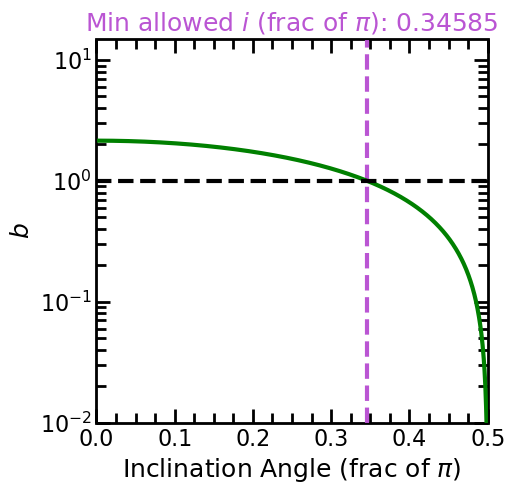

In [2]:
a = 0.01 #semi major axis in AU

fig, ax = plt.subplots(1,1,figsize = (5,5))
angle = np.linspace(0, np.pi/2.0, 1000)
Rs = 0.00465047
b = a*np.cos(angle)/Rs

plt.xlabel(r'Inclination Angle (frac of $\pi$)', fontsize = 18)
plt.ylabel(r'$b$', fontsize = 18)

ind = np.argmin(abs(b-1.0))
plt.title(r'Min allowed $i$ (frac of $\pi$): ' + str( round(angle[ind]/np.pi, 5)), fontsize = 18, color = 'mediumorchid')

plt.axvline(angle[ind]/np.pi, color = 'mediumorchid', lw = 3, ls = '--')
plt.plot(angle/np.pi, b, 'g-', lw = 3)

plt.axhline(1.0, color = 'k', lw = 3, ls = '--')
plt.yscale('log')

plt.tight_layout()
plt.ylim(10**(-2), 15)
plt.xlim(0,0.5)

ax.xaxis.set_major_locator(MultipleLocator(0.1))
ax.xaxis.set_minor_locator(MultipleLocator(0.025))

ax.patch.set_edgecolor('black')  
ax.patch.set_linewidth(2)  
ax.tick_params(which = 'major', direction = 'in', length = 10, top = True,  right = True, width = 2, labelsize = 16)
ax.tick_params(which = 'minor', direction = 'in',length = 7,  top = True,  right = True, width = 2)


#plt.xticks([])


# Light curve models 

Now let's model some actual light curves! Mess around with the parameters and discuss how the light curves change as a function of each with your coursemates. 

All light curves are generate using the function lc_model from the functions.py file, which implements the transit approximation from this paper https://iopscience.iop.org/article/10.1086/592321/pdf. Below are both static and animated versions. Feel free to work with which ever one works better with your brain! The input parameters are as follow:

- Planet radius: $R_p$ (in $R_\oplus$ units), 
- Stellar radius: $R_s$ (also in $R_\oplus$ units)
- semi-major axis: $a$ (in AU)
- inclination angle: $i$ (in radians)

Note: be careful with you choice of inclination angle. Make sure you stay below b=1 or the code will break. Also, the approximation I'm using gets less accurate as b approaches 1 (i.e., grazing transits) and the top and bottom panels of the animation may not line up exactly, but you should still be able to get the basic idea.

## Static light curve models!
Any figures you run below will be saved in the figures subdirectory of this module. Comment out or modify the last two lines in the code cell to change this behavior. The X axis limits are set up to be auto determined by the light curve. You might want to change these to some logical fixed values for all your plots so you can really notice the differences when comparing 2+ plots (particularly when changing a or i)!

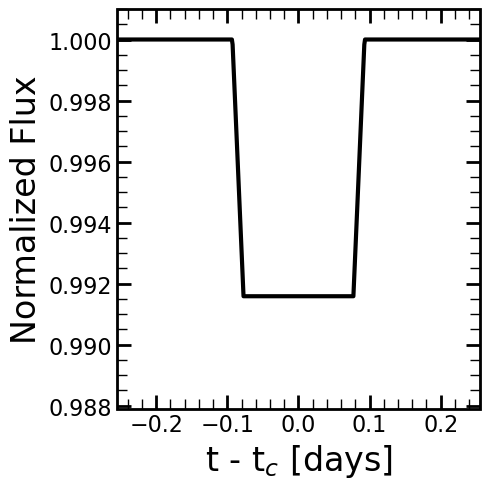

In [3]:
#input parameters
Rp = 10.0  # planet radius in Earth units
Rs = 109.0  # star radius in Earth units
a = 0.1   # semi major axis in AU
i = 1.0*(np.pi/2.0)  # inclination angle

Any figures you run below will be saved in the figures subdirectory of this module. Comment out or modify the last two lines in the code cell to change this behavior.

fig, ax = plt.subplots(1,1, figsize = (5,5))

flux, tt, tc, b, z = lc_model(Rp = Rp, Rs = Rs, a = a, inc = i, npts = 1000)

ax.set_aspect('equal')

star_ms = (((tc-tt[np.where(np.diff(flux)<0)[0][0]])/(tc-min(tt)))*252)
star_ms = star_ms - (Rp/Rs)*star_ms
planet_ms = (Rp/Rs)*star_ms

ax.plot(tt-tc, flux, 'w-', linewidth = 0)
ax.set_xlim(min(tt-tc), max(tt-tc))
ax.set_aspect('auto','box')

ax.set_xlabel(r't - t$_c$ [days]', fontsize = 24)
ax.set_ylabel(r'Normalized Flux', fontsize = 24)

ax.set_ylim(1.0 - 0.11**2, 1.001)

from matplotlib.ticker import MultipleLocator

ax.yaxis.set_major_locator(MultipleLocator(0.002))
ax.yaxis.set_minor_locator(MultipleLocator(0.0005))
xmaj = (max(tt)-min(tt))/5
xmaj = round(xmaj, -int(np.floor(np.log10(abs(xmaj)))))

ax.xaxis.set_major_locator(MultipleLocator(xmaj))
ax.xaxis.set_minor_locator(MultipleLocator(xmaj/5))

ax.tick_params(which = 'major', direction = 'in', top = True, right = True, length = 10, width = 2, 
                  labelsize = 16)
ax.tick_params(which = 'minor', direction = 'in', top = True, right = True, length = 7.5, width = 1)

ax.plot(tt-tc, flux, lw = 3, color = 'k')

ax.patch.set_edgecolor('black')  
ax.patch.set_linewidth(2) 
plt.tight_layout()

figname = f'Rp= {Rp}Re_Rs={Rs}Re_a={a}AU_i={i}rad'
plt.savefig(f'./figures/light_curves/{figname}.png', dpi = 300)

## Animated light curve models!

Any animations your run below will be saved in the animations subdirectory of this module. The animations take maybe 20 seconds to compile. If you don't feel like waiting or making your own, I have include some pregenerated animations with the module as well (./animations/pregenerated) which are seperated into the following:

- 'changes in radius': shows transit for $R_p = 1 \;R_\oplus, 5\; R_\oplus, \mathrm{and} \; 10 \; R_\oplus$ with $i = \pi/2$
- 'changes in inclination angle': shows $i = \pi/2, 0.9\times\pi/2, 0.8\times\pi/2, 0.7\times\pi/2$ for a $10 \; R_\oplus$ planet at 0.01 AU.
- 'changes in semi-major axis for slightly inclined orbit': I fixed $R_p = 10 R_\oplus$ and $i = 0.999\times\pi/2$ (so slightly inclined). The animations show a = 0.01, 0.1, 1.0,and 2.0 AU.

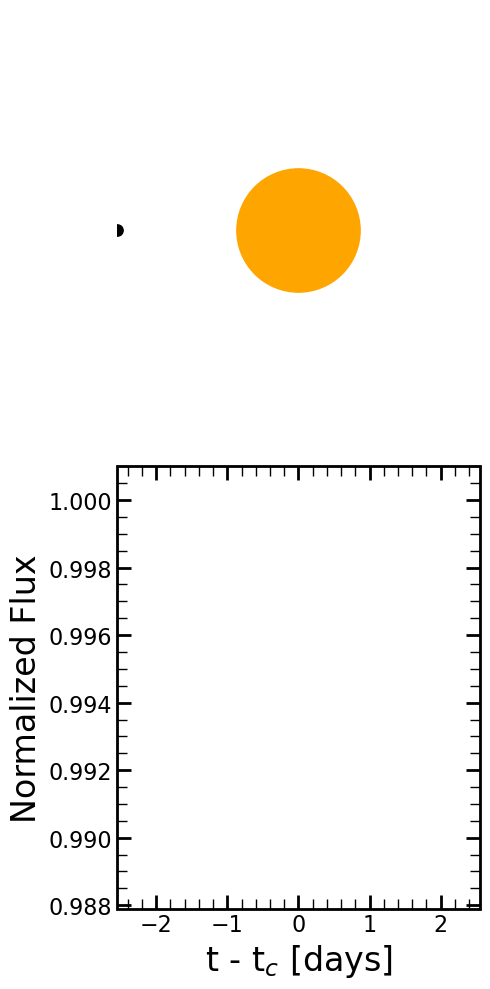

In [65]:
#input parameters
Rp = 10.0 
Rs = 109.0
a = 10.0
i = 1.0*(np.pi/2.0)


from matplotlib.animation import FuncAnimation
import matplotlib.animation

fig, ax = plt.subplots(2,1, figsize = (5,10))

flux, tt, tc, b, z = lc_model(Rp = Rp, Rs = Rs, a = a, inc = i, npts = 100)
ax[0].set_axis_off()

ax[0].set_xlim(-max(z), max(z))
ax[0].set_ylim(-max(z), max(z))
ax[0].set_aspect('equal', 'box')

ax[1].set_xlim(min(tt-tc), max(tt-tc))
ax[1].set_aspect('equal')

star_ms = (((tc-tt[np.where(np.diff(flux)<0)[0][0]])/(tc-min(tt)))*252)
star_ms = star_ms - (Rp/Rs)*star_ms
planet_ms = (Rp/Rs)*star_ms

ax[0].plot(0,0, markersize = star_ms, color = 'orange', marker = 'o')

pl, = ax[0].plot([], [], marker = 'o', color = 'k', markersize = planet_ms)
l, = ax[1].plot([],[], 'k-', linewidth = 3);

ax[0].set_aspect('auto','box')

ax[1].plot(tt-tc, flux, 'w-', linewidth = 0)
ax[1].set_xlim(min(tt-tc), max(tt-tc))
ax[1].set_aspect('auto','box')

ax[1].set_xlabel(r't - t$_c$ [days]', fontsize = 24)
ax[1].set_ylabel(r'Normalized Flux', fontsize = 24)

ax[1].set_ylim(1.0 - 0.11**2, 1.001)

from matplotlib.ticker import MultipleLocator

ax[1].yaxis.set_major_locator(MultipleLocator(0.002))
ax[1].yaxis.set_minor_locator(MultipleLocator(0.0005))
xmaj = (max(tt)-min(tt))/5
xmaj = round(xmaj, -int(np.floor(np.log10(abs(xmaj)))))

ax[1].xaxis.set_major_locator(MultipleLocator(xmaj))
ax[1].xaxis.set_minor_locator(MultipleLocator(xmaj/5))

ax[1].tick_params(which = 'major', direction = 'in', top = True, right = True, length = 10, width = 2, 
                  labelsize = 16)
ax[1].tick_params(which = 'minor', direction = 'in', top = True, right = True, length = 7.5, width = 1)

ax[1].patch.set_edgecolor('black')  
ax[1].patch.set_linewidth(2) 
plt.tight_layout()

sign = (tt-tc)/abs(tt-tc)


def animate(i):
    x = np.array([])
    y = np.array([])
    sign = (tt[i]-tc)/abs(tt[i]-tc)
    x = np.append(x, sign*z[i])
    y = np.append(y, b)
    pl.set_data(x, y)

    l.set_data(tt[:i+1]-tc, flux[:i+1])
    plt.pause(0.001)

ani = matplotlib.animation.FuncAnimation(fig, animate, frames=len(tt))

from IPython.display import HTML
HTML(ani.to_jshtml())


writer = matplotlib.animation.PillowWriter(fps=15,
                                 metadata=dict(artist='Me'),
                                 bitrate=1800)
gifname = f'Rp= {Rp}Re_Rs={Rs}Re_a={a}AU_i={i}rad'
ani.save('./animations/' + gifname + '.gif', writer=writer)
